# Exploratory Data Analysis (EDA) of Raw ESC-50 Data

This notebook performs a comprehensive exploratory data analysis on the raw ESC-50 dataset. The goal is to verify the dataset structure, analyze audio features, and visually inspect spectral characteristics before further processing.

## Objectives
1. **Structural Analysis**: Verify dataset integrity (file counts, classes, sampling rates, etc.).
2. **Extended Descriptive Statistics**: Compute and analyze features like RMS Energy, Zero Crossing Rate, and Spectral characteristics.
3. **Class Balance**: Confirm the dataset is balanced across classes and folds.
4. **Visual Spectral Analysis**: Compare Mel-spectrograms of different sound categories.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm.notebook import tqdm

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Structural Analysis

We start by loading the metadata and verifying the basic properties of the dataset.

In [2]:
# Paths
DATA_PATH = "../data/raw/ESC-50-master"
META_FILE = os.path.join(DATA_PATH, "meta/esc50.csv")
AUDIO_DIR = os.path.join(DATA_PATH, "audio")

# Load Metadata
try:
    df = pd.read_csv(META_FILE)
    print("Metadata loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: Metadata file not found at {META_FILE}")


Metadata loaded successfully.


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


### Verification Checks
We verify the following:
- Total files: 2000
- Classes: 50
- Samples per class: 40
- Folds: 5

In [3]:
n_files = len(df)
n_classes = df['category'].nunique()
samples_per_class = df['category'].value_counts().unique()
n_folds = df['fold'].nunique()

print(f"Total Audio Files: {n_files}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Number of Folds: {n_folds}")

# Check for missing values
missing_values = df.isnull().sum().sum()
print(f"Missing Values: {missing_values}")

assert n_files == 2000, "Expected 2000 files"
assert n_classes == 50, "Expected 50 classes"
assert len(samples_per_class) == 1 and samples_per_class[0] == 40, "Classes are not balanced"
assert missing_values == 0, "Dataset contains missing values"

Total Audio Files: 2000
Number of Classes: 50
Samples per Class: [40]
Number of Folds: 5
Missing Values: 0


### Audio Properties Check
We verify that all files have the expected duration (5s) and sample rate (44.1kHz). Calculating this for all 2000 files might take a moment.

In [4]:
durations = []
sample_rates = []

# Check first 100 files for quick verification, or all for thorough check
# Using a subset for speed in demonstration, but verifying specific files is good practice.
print("Checking audio properties for a subset of files...")

check_files = df['filename'].tolist() # Check all

for fname in tqdm(check_files):
    path = os.path.join(AUDIO_DIR, fname)
    if os.path.exists(path):
        # librosa.get_duration and get_samplerate are fast if just header is read, but lets create an object for robustness if needed
        # For speed: Use librosa.get_duration(filename=path)
        # For sample rate: we usually load with sr=None to get original
        try:
            sr = librosa.get_samplerate(path)
            dur = librosa.get_duration(path=path)
            durations.append(dur)
            sample_rates.append(sr)
        except Exception as e:
            print(f"Error reading {fname}: {e}")

# Analyze
unique_sr = set(sample_rates)
unique_dur = set(durations)

print(f"Unique Sample Rates: {unique_sr}")
print(f"Duration Stats: Min={min(durations):.2f}s, Max={max(durations):.2f}s")

if len(unique_sr) == 1 and 44100 in unique_sr:
    print("✔ All files have 44.1kHz sample rate.")
else:
    print("⚠ Inconsistent sample rates found.")

if all(d == 5.0 for d in durations):
    print("✔ All files are exactly 5 seconds.")
else:
    print("⚠ Duration variations found (likely minor precision diffs).")

Checking audio properties for a subset of files...


  0%|          | 0/2000 [00:00<?, ?it/s]

Unique Sample Rates: {44100}
Duration Stats: Min=5.00s, Max=5.00s
✔ All files have 44.1kHz sample rate.
✔ All files are exactly 5 seconds.


## 2. Extended Descriptive Statistics

We will compute acoustic features for all files to understand the spectral diversity of the dataset.

**Features:**
- **RMS Energy**: Root Mean Square energy (loudness).
- **Zero Crossing Rate (ZCR)**: Rate of sign changes (noisiness).
- **Spectral Centroid**: Center of mass of the spectrum (brightness).
- **Spectral Bandwidth**: Width of the spectral band (timbre).
- **Spectral Roll-off**: Frequency below which a percentage of total energy lies.

In [5]:
feature_data = []

print("Extracting features...")
for idx, row in tqdm(df.iterrows(), total=len(df)):
    path = os.path.join(AUDIO_DIR, row['filename'])
    try:
        y, sr = librosa.load(path, sr=None) # Load original SR
        
        # Extract features (using mean for global stats)
        rms = np.mean(librosa.feature.rms(y=y))
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))
        cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        bw = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
        rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
        
        feature_data.append({
            'filename': row['filename'],
            'category': row['category'],
            'fold': row['fold'],
            'rms': rms,
            'zcr': zcr,
            'centroid': cent,
            'bandwidth': bw,
            'rolloff': rolloff
        })
    except Exception as e:
        print(f"Error processing {row['filename']}: {e}")

feat_df = pd.DataFrame(feature_data)

Extracting features...


  0%|          | 0/2000 [00:00<?, ?it/s]

### Global Statistics

In [6]:
feat_df.describe().round(2)

,fold,rms,zcr,centroid,bandwidth,rolloff
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,3.00,0.07,0.08,2935.79,2998.53,5734.62
std,1.41,0.08,0.07,1764.06,1251.11,3408.51
min,1.00,0.00,0.00,119.92,216.98,134.30
25%,2.00,0.02,0.03,1570.59,2063.97,2784.85
50%,3.00,0.05,0.06,2615.48,3002.79,5258.40
75%,4.00,0.10,0.10,3917.74,3984.30,8206.39
max,5.00,0.69,0.67,13554.66,6791.53,17534.37


### Feature Distributions by Class
We visualize how these features differ across categories. Since there are 50 classes, we'll plot a subset or aggregate views first.

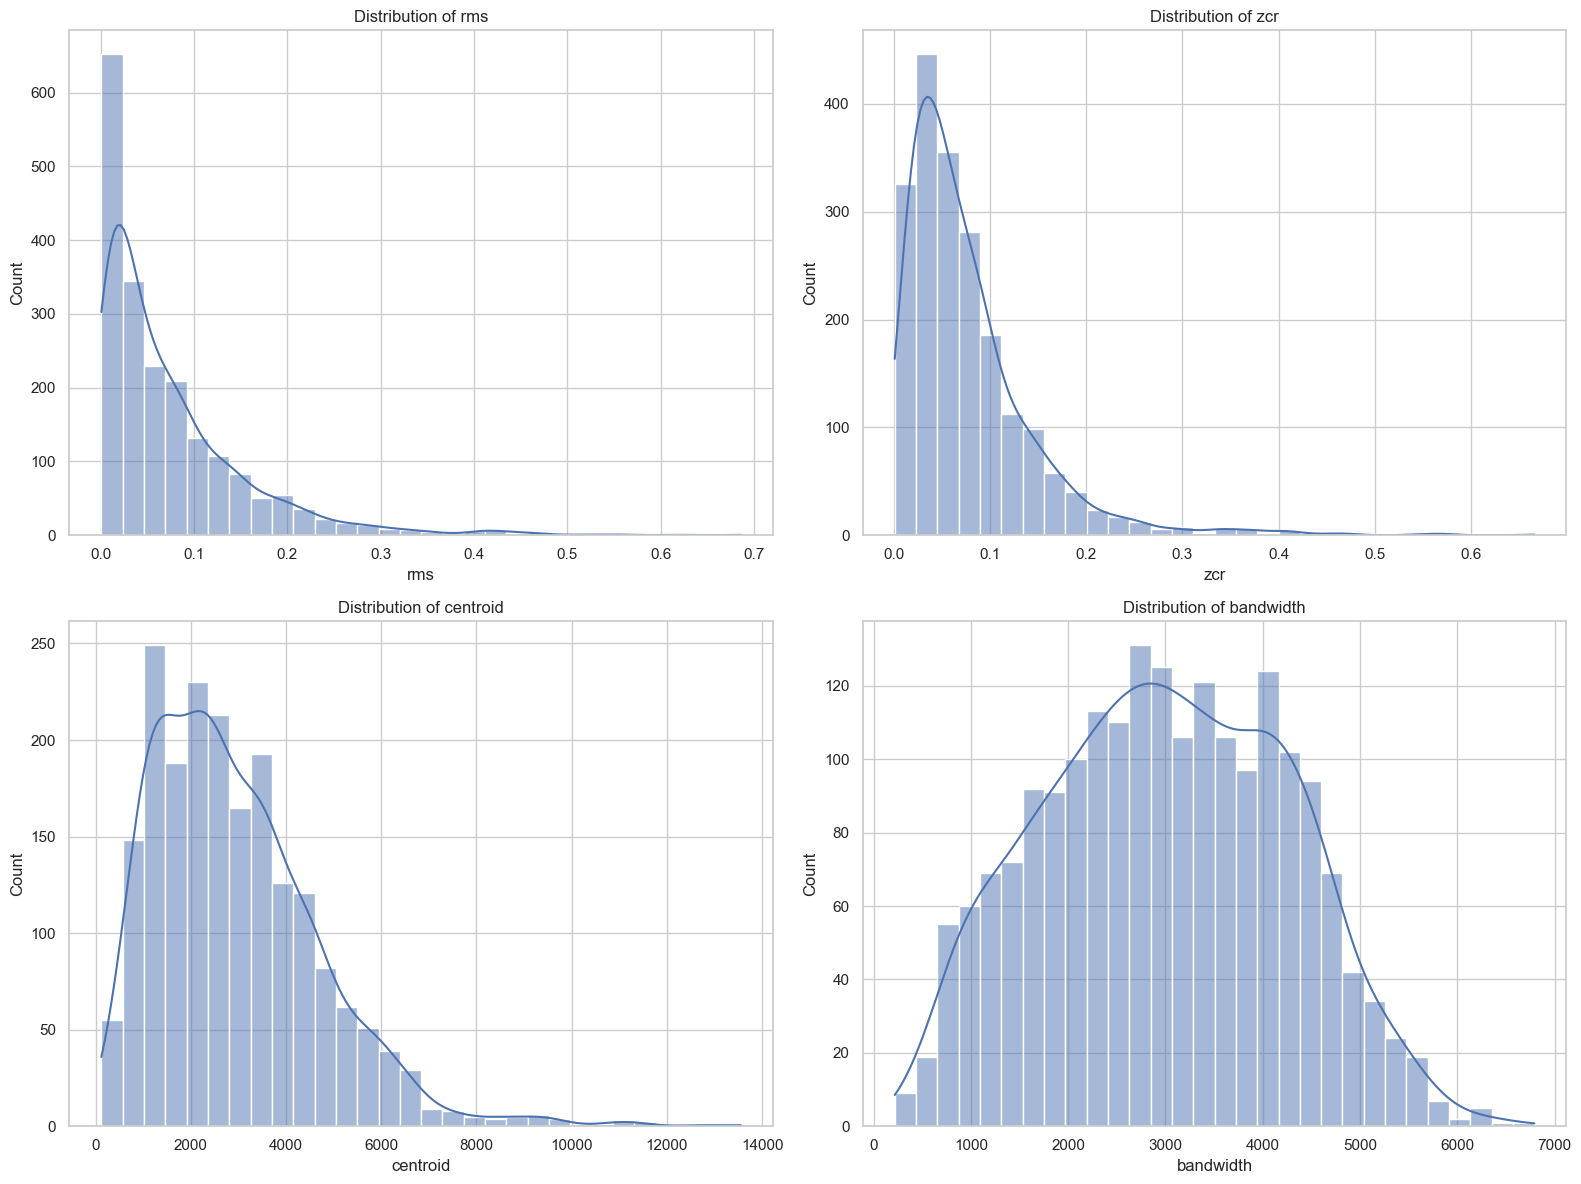

In [7]:
features_to_plot = ['rms', 'zcr', 'centroid', 'bandwidth']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, feature in enumerate(features_to_plot):
    ax = axes[i//2, i%2]
    sns.histplot(feat_df[feature], kde=True, ax=ax, bins=30)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    
plt.tight_layout()
plt.show()

### Boxplots by Category (Subset)
To see distinct acoustic profiles, let's pick 10 diverse classes and compare their Spectral Centroid.

/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_38611/259286419.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='centroid', data=subset_df, palette='viridis')


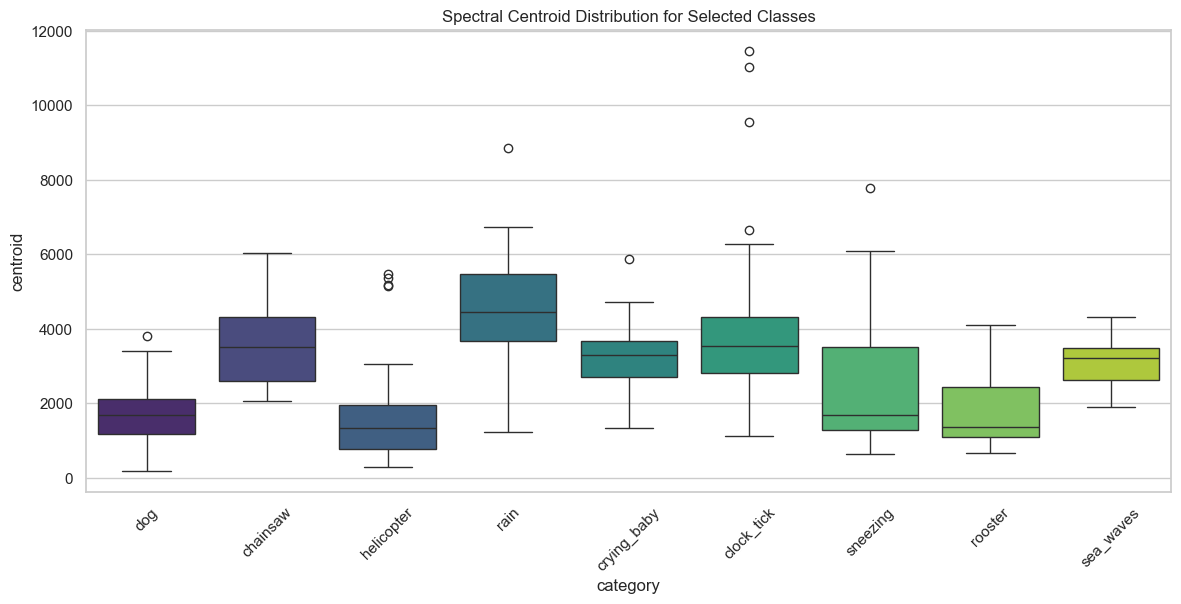

In [8]:
selected_classes = ['dog', 'rain', 'sea_waves', 'crying_baby', 'clock_tick', 
                    'sneezing', 'helicopter', 'chainsaw', 'rooster', 'fire_crackling']

subset_df = feat_df[feat_df['category'].isin(selected_classes)]

plt.figure(figsize=(14, 6))
sns.boxplot(x='category', y='centroid', data=subset_df, palette='viridis')
plt.title('Spectral Centroid Distribution for Selected Classes')
plt.xticks(rotation=45)
plt.show()

## 3. Analysis of Class Balance

Visual demonstration that the dataset is perfectly balanced.

/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_38611/3398507774.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='category', data=df, palette='hls')


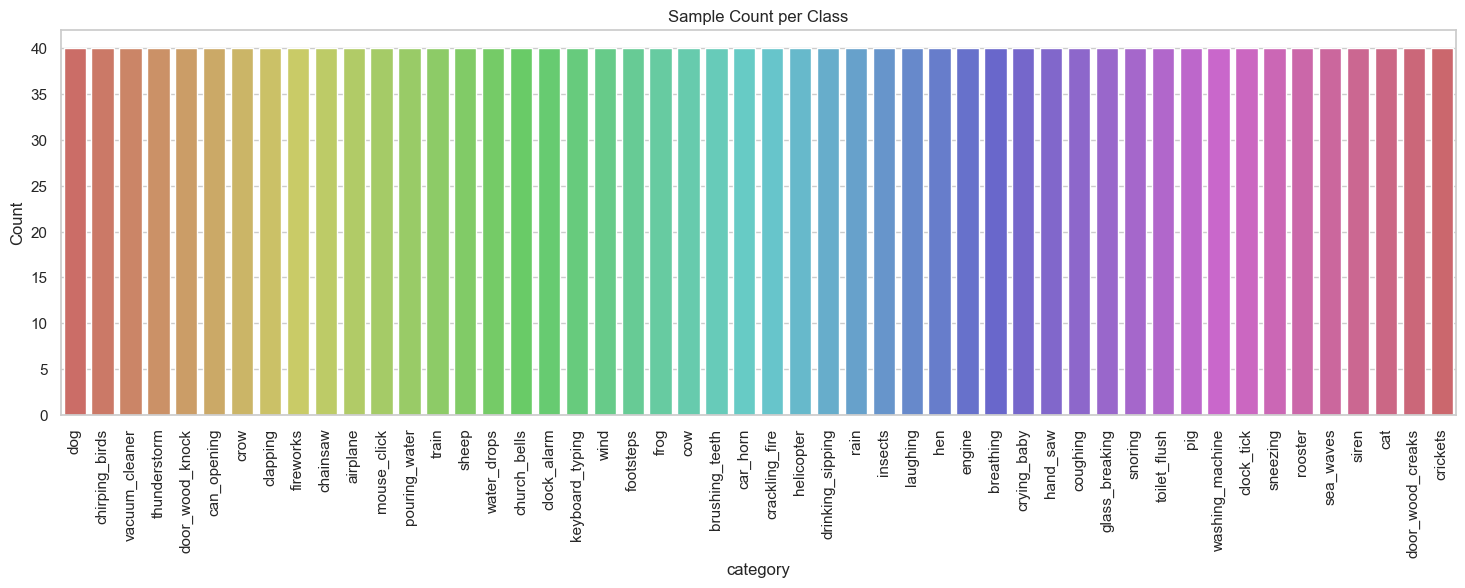

In [9]:
plt.figure(figsize=(18, 5))
sns.countplot(x='category', data=df, palette='hls')
plt.title('Sample Count per Class')
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.show()

### Fold Distribution
Verifying that samples are evenly distributed across the 5 predefined folds for cross-validation.

In [10]:
fold_counts = df.groupby(['fold', 'category']).size().reset_index(name='count')

# Check if any class in any fold has != 8 samples (since 40 samples / 5 folds = 8)
imbalance = fold_counts[fold_counts['count'] != 8]

if imbalance.empty:
    print("✔ Perfect Balance: Each class contains exactly 8 samples per fold.")
else:
    print("⚠ Imbalance detected in folds:")
    display(imbalance)

✔ Perfect Balance: Each class contains exactly 8 samples per fold.


## 4. Visual Spectral Analysis

We investigate the time-frequency characteristics of different sound types. We categorize them manually to observe distinct patterns.

- **Periodic**: Structure that repeats (e.g., siren).
- **Impulse**: Short, sharp bursts (e.g., door knock).
- **Noise-like**: Broadband, unstructured (e.g., rain).
- **Tonal**: Harmonic structure (e.g., engine, or musical instrument if present).

Verifying class names for visualization...


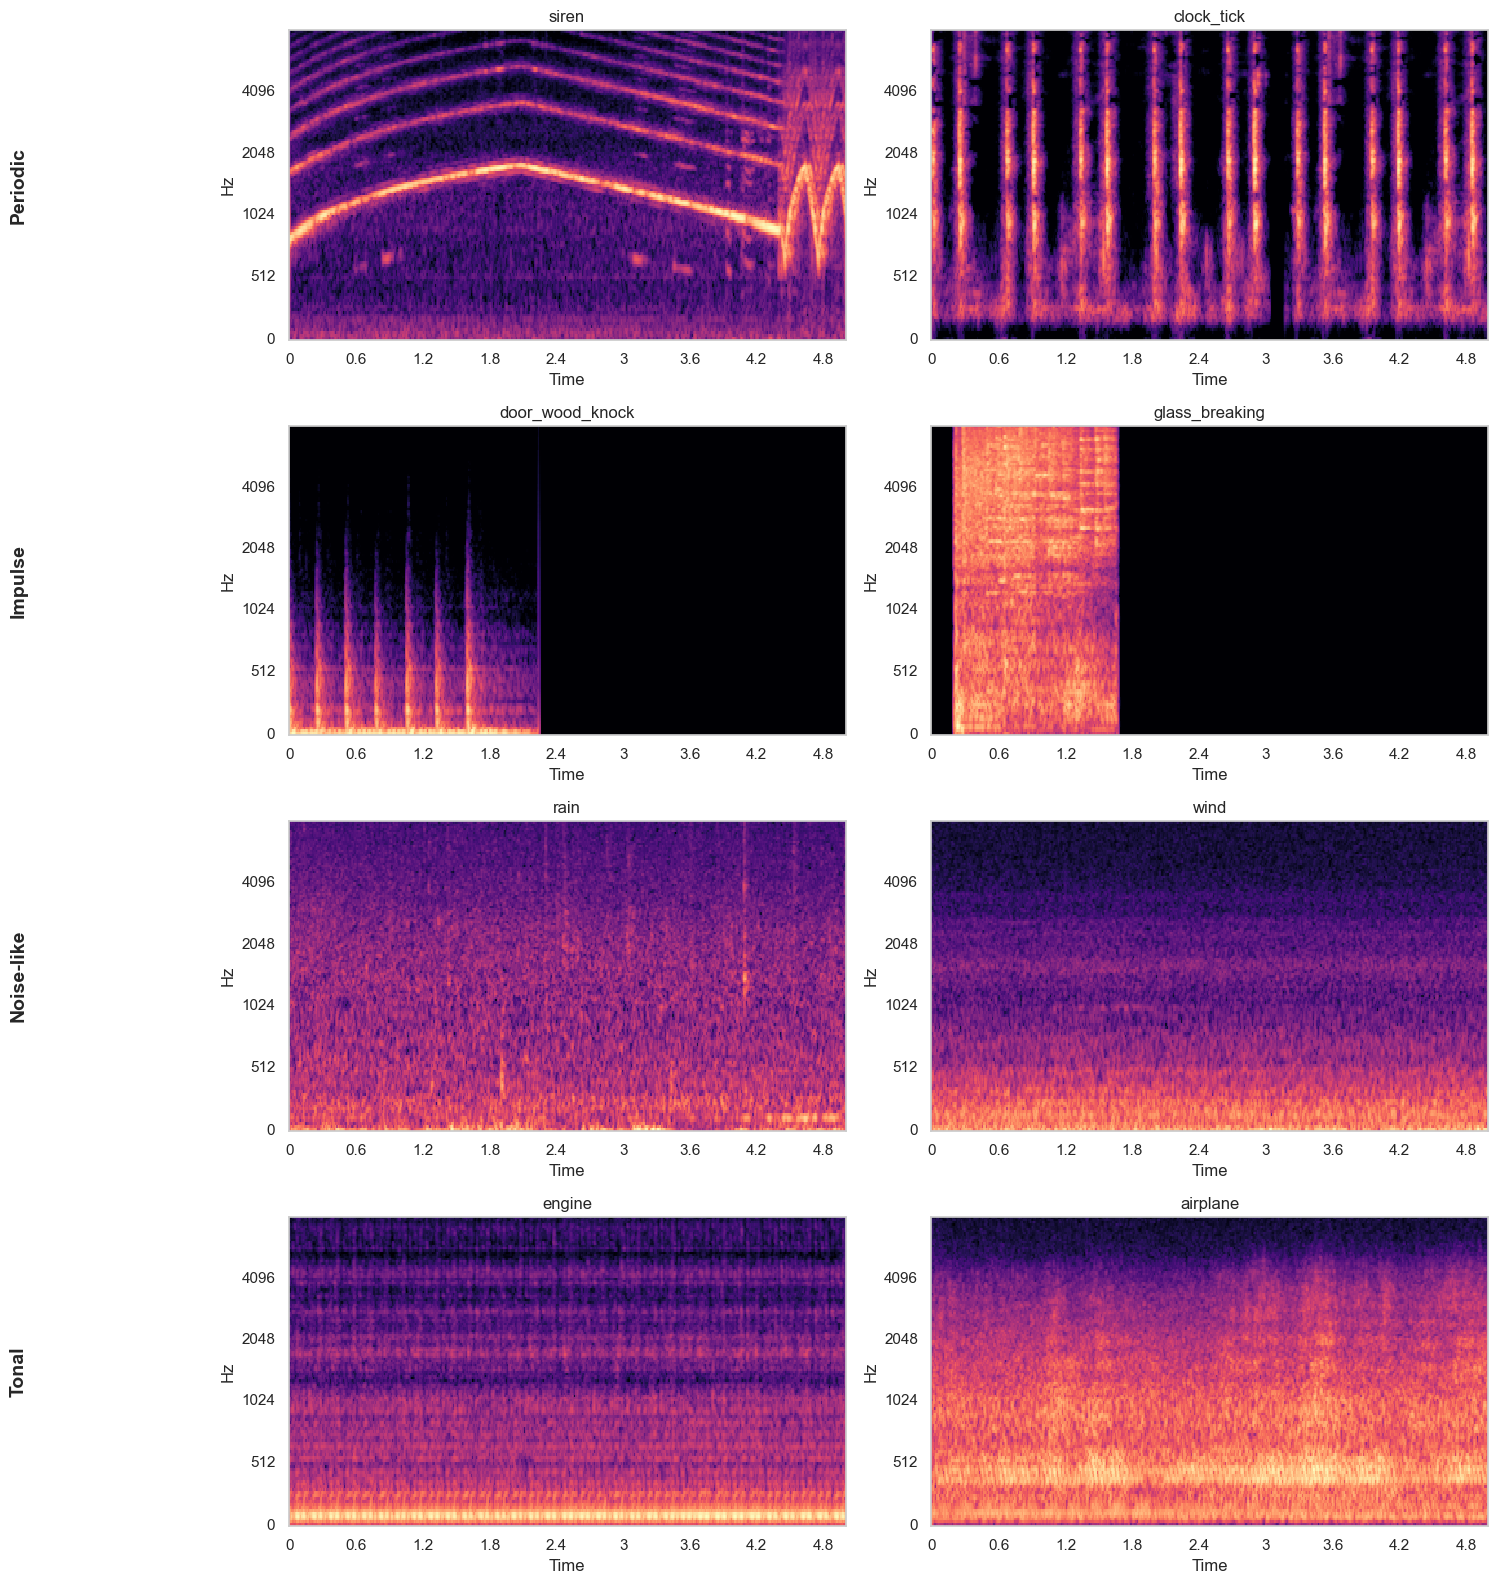

In [11]:
def plot_mel_spectrogram(category_name, ax):
    # Select a random file from this category
    sample = df[df['category'] == category_name].sample(1).iloc[0]
    path = os.path.join(AUDIO_DIR, sample['filename'])
    
    y, sr = librosa.load(path, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000, ax=ax)
    ax.set_title(f'{category_name}')

categories_to_view = {
    'Periodic': ['siren', 'clock_tick'],
    'Impulse': ['door_wood_knock', 'glass_breaking'],  # Adjusted exact names from ESC-50 usually 'door_wood_knock'
    'Noise-like': ['rain', 'wind'],
    'Tonal': ['engine', 'airplane']
}

# Note: ensuring category names exist in dataframe
# Let's verify names first just in case of slight typo in request vs dataset
available_classes = df['category'].unique()
print("Verifying class names for visualization...")
# Adjusting based on actual ESC-50 names if needed (e.g. 'door_knock' might be 'door_wood_knock')

fig, axes = plt.subplots(4, 2, figsize=(15, 16))

row = 0
for chart_type, classes in categories_to_view.items():
    for i, cls in enumerate(classes):
        # Find close match if exact not found
        if cls not in available_classes:
            # Simple flexible search
            candidates = [c for c in available_classes if cls in c]
            if candidates:
                cls = candidates[0]
        
        if cls in available_classes:
            plot_mel_spectrogram(cls, axes[row, i])
        else:
            print(f"Class '{cls}' not found, skipping plot.")
    
    # Label the group (on the left plot)
    axes[row, 0].text(-0.5, 0.5, chart_type, transform=axes[row, 0].transAxes, 
                      fontsize=14, weight='bold', verticalalignment='center', rotation=90)
    row += 1

plt.tight_layout()
plt.show()

### Analytic Observations

Based on the spectrograms:
1. **Spectral Similarity**: Classes like 'Rain' and 'Wind' show broadband energy across many frequencies, making them potentially harder to distinguish without temporal cues.
2. **Distinctiveness**: 'Siren' shows clear, shifting tonal lines, while 'Clock Tick' shows regular, equidistant vertical spikes (transients).
3. **Confusion Potential**: Continuous mechanical sounds like 'Engine' and 'Airplane' share low-frequency dominance and stationary characteristics, posing a challenge for classifiers.